In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch import nn
from torch.utils.data import DataLoader

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



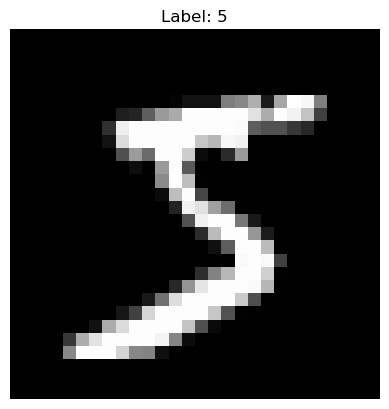

In [4]:
data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

image, label = data[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [5]:
targets = data.targets.numpy()
idx = list(range(len(data)))

train_idx, val_idx = train_test_split(
    idx,
    test_size=0.2,
    stratify=targets,
    random_state=42,
    shuffle=True
)

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)

In [6]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

batch_size = 64

train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)


mps


In [7]:
len(test_data)

10000

In [8]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)

#changable
loss_fn = nn.CrossEntropyLoss()
#changable
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    

In [10]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.311697  [   64/48000]
loss: 0.329643  [ 6464/48000]
loss: 0.175863  [12864/48000]
loss: 0.127108  [19264/48000]
loss: 0.301221  [25664/48000]
loss: 0.248831  [32064/48000]
loss: 0.110576  [38464/48000]
loss: 0.104952  [44864/48000]
Test Error: 
 Accuracy: 96.0%, Avg loss: 0.126941 

Epoch 2
-------------------------------
loss: 0.186892  [   64/48000]
loss: 0.069273  [ 6464/48000]
loss: 0.104327  [12864/48000]
loss: 0.052448  [19264/48000]
loss: 0.116516  [25664/48000]
loss: 0.134017  [32064/48000]
loss: 0.054037  [38464/48000]
loss: 0.049210  [44864/48000]
Test Error: 
 Accuracy: 96.8%, Avg loss: 0.101508 

Epoch 3
-------------------------------
loss: 0.076067  [   64/48000]
loss: 0.063258  [ 6464/48000]
loss: 0.089668  [12864/48000]
loss: 0.011842  [19264/48000]
loss: 0.043097  [25664/48000]
loss: 0.116155  [32064/48000]
loss: 0.028261  [38464/48000]
loss: 0.068285  [44864/48000]
Test Error: 
 Accuracy: 96.6%, Avg loss: 0.113911 

Epoc

In [11]:
model.eval()
i = 10
x, y = test_data[i][0], test_data[i][1]
with torch.no_grad():
    x=x.to(device)
    logits = model(x.to(device))
    probs = torch.softmax(logits, dim=1)
    predicted, actual, c = probs[0].argmax(0), y, probs[0]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')
    print(c)

Predicted: "0", Actual: "0"
tensor([1.0000e+00, 1.8123e-16, 3.3264e-12, 1.0189e-16, 1.6449e-14, 2.4744e-16,
        5.7396e-13, 1.0295e-14, 1.6308e-15, 5.3495e-11], device='mps:0')
